In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import sys
module_path = "../eagleeye"
sys.path.append(module_path)
import EagleEye
from utils_EE import compute_the_null, partitioning_function

colours = {
    "blue": "#6495ec",
    "green": "#93d4c0",
    "pink": "#eeadd5",
    "lightblue": "#afbcda",
    "red": "#dc143c",
}

## Generate the datasets

In [38]:
sys.path.append("../examples/Tresette_v7")
from utils_37 import generate_uniform_with_Gaussian_ove_under

num_points = 50000
anomaly_sizes_o = [50, 100, 200, 300, 500]
anomaly_sizes_u = [100, 300, 700]
n_dim = 3

X, Y = generate_uniform_with_Gaussian_ove_under(n_dim, num_points, anomaly_sizes_o, anomaly_sizes_u)

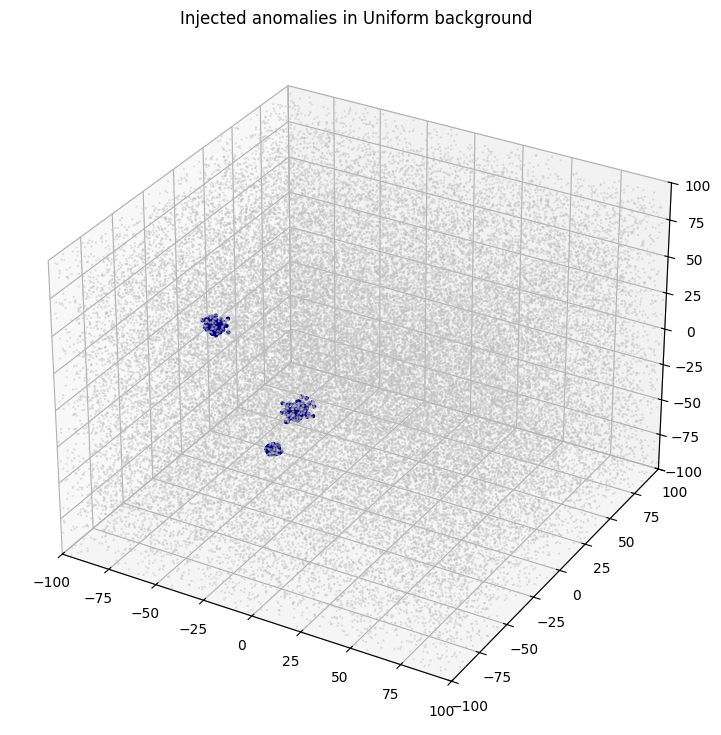

In [44]:
from utils_37 import plot_injected_anomalies_in_uniform_background
plot_injected_anomalies_in_uniform_background(X, anomaly_sizes_u, Y, anomaly_sizes_o)

## EagleEye

In [7]:
p = len(Y) / (len(Y) + len(X))
K_M = 300
p_ext = 1e-5
n_jobs = 8

In [8]:
stats_null = compute_the_null(p=p, K_M=K_M)

In [9]:
import time
t = time.time()
result_dict, stats_null = EagleEye.Soar(X, Y, K_M=K_M, p_ext=p_ext, n_jobs=n_jobs, stats_null=stats_null, result_dict_in={}, do_IDE=True)
elapsed = time.time() - t
print(f"Elapsed time: {elapsed:.2f} seconds")

-----------------------------------------------------------------
Eagle...Soar!
-----------------------------------------------------------------
Compute the nearest neighbours
KNN completed: 0.00 %
KNN completed: 10.00 %
KNN completed: 20.00 %
KNN completed: 30.00 %
KNN completed: 40.00 %
KNN completed: 50.00 %
KNN completed: 60.00 %
KNN completed: 70.00 %
KNN completed: 80.00 %
KNN completed: 90.00 %
-----------------------------------------------------------------
Flagging of putative anomalous points
-----------------------------------------------------------------


<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

...

<IPython.core.display.Math object>

'DONE!'

<IPython.core.display.Math object>

'DONE!'

Elapsed time: 8.34 seconds


In [10]:
clusters = partitioning_function(X, Y, result_dict, p_ext=p_ext, Z=2.65)
EE_book = EagleEye.Repechage(X, Y, result_dict, clusters, p_ext=p_ext)

-----------------------------------------------------------------
Clustering
-----------------------------------------------------------------
-----------------------------------------------------------------
Repêchage
-----------------------------------------------------------------


/Users/myhr/Documents/Environments/eagleeye/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<IPython.core.display.Math object>

alpha = 1
alpha = 2
alpha = 3
alpha = 4
alpha = 5


'DONE!'

<IPython.core.display.Math object>

alpha = 1
alpha = 2
alpha = 3


'DONE!'

In [11]:
banned_Y = {
    pruned_index for cluster in EE_book["Y_OVER_clusters"].values() if cluster["Pruned"] is not None for pruned_index in cluster["Pruned"]
}
equalized_Y = [x for x in range(Y.shape[0]) if x not in banned_Y]
equalized_neighbours = result_dict["Knn_model"].kneighbors(Y[equalized_Y, :])[1]

nx = X.shape[0]
mask = ~np.isin(equalized_neighbours, [x + nx for x in banned_Y])

filtered_equalized_neighbors = np.empty((equalized_neighbours.shape[0], K_M), dtype=int)
for i in range(equalized_neighbours.shape[0]):
    valid_neighbors = equalized_neighbours[i, :][mask[i, :]]
    if valid_neighbors.size < K_M:
        raise ValueError(f"Row {i} does not have enough valid neighbors.")
    filtered_equalized_neighbors[i, :] = valid_neighbors[:K_M]
    
binary_seq = (filtered_equalized_neighbors >= nx).astype(int)

from EagleEye import PValueCalculator
KSTAR_RANGE = range(20, K_M)
p_val_info_eq = PValueCalculator(binary_seq, KSTAR_RANGE, p=p)
Upsilon_i_equalized_Y = p_val_info_eq.min_pval_plus
Upsilon_i_equalized_Y

array([ 4.68,  0.48,  0.88, ...,  6.42, 11.42,  9.8 ])

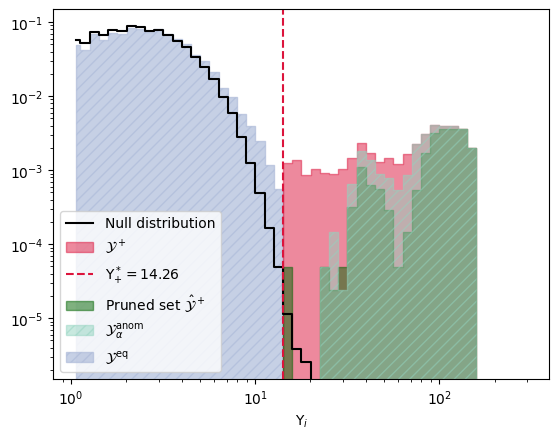

In [37]:
bins = np.logspace(0, 2.5, 51)
# bins = np.linspace(0, 120, 51)
cents = 0.5 * (bins[1:] + bins[:-1])
widths = np.diff(bins)
null_dist, _ = np.histogram(result_dict["stats_null"][p], bins=bins, density=False)
plt.step(cents, null_dist / np.sum(null_dist), where="mid", label="Null distribution", color='k', alpha=1, zorder=2)

# Upsilon_Y, _ = np.histogram(result_dict["Upsilon_i_Y"], bins=bins, density=False)
# plt.fill_between(cents, Upsilon_Y / np.sum(Upsilon_Y), step="mid", color=colours["red"], alpha=0.5, label=r"$\mathcal{Y}$")

Y_plus, _ = np.histogram(result_dict["Upsilon_i_Y"][result_dict["Y^+"]], bins=bins, density=False)
plt.fill_between(cents, Y_plus / np.sum(Upsilon_Y), step="mid", color=colours["red"], alpha=0.5, label=r"$\mathcal{Y}^+$")

Upsilon_star_plus = result_dict["Upsilon_star_plus"][p_ext]
plt.axvline(Upsilon_star_plus, color=colours["red"], linestyle="--", label=r"$\Upsilon^*_{+}=$" + f"{Upsilon_star_plus:.2f}")

Y_pruned, _ = np.histogram(result_dict["Upsilon_i_Y"][result_dict["Y_Pruned"][p_ext]], bins=bins, density=False)
plt.fill_between(cents, Y_pruned / np.sum(Upsilon_Y), step="mid", color="darkgreen", alpha=0.5, label=r"Pruned set $\hat\mathcal{Y}^+$")

idx = [item for cluster in EE_book["Y_OVER_clusters"].values() for item in cluster.get("Repechaged", [])]
Y_repechage, _ = np.histogram(result_dict["Upsilon_i_Y"][idx], bins=bins, density=False)
plt.fill_between(cents, Y_repechage / np.sum(Upsilon_Y), step="mid", hatch="///", color=colours["green"], alpha=0.5, label=r"$\mathcal{Y}_\alpha^{\text{anom}}$")

Y_eq, _ = np.histogram(Upsilon_i_equalized_Y, bins=bins, density=False)
plt.fill_between(cents, Y_eq / np.sum(Upsilon_Y), step="mid", color=colours["lightblue"], hatch="///", alpha=0.7, label=r"$\mathcal{Y}^{\mathrm{eq}}$", zorder=0)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\Upsilon_i$")
plt.legend()

In [35]:
banned_X = {
    pruned_index for cluster in EE_book["X_OVER_clusters"].values() if cluster["Pruned"] is not None for pruned_index in cluster["Pruned"]
}
equalized_X = [x for x in range(X.shape[0]) if x not in banned_X]
equalized_neighbours = result_dict["Knn_model"].kneighbors(X[equalized_X, :])[1]

nx = X.shape[0]
mask = ~np.isin(equalized_neighbours, [x for x in banned_X])

filtered_equalized_neighbors = np.empty((equalized_neighbours.shape[0], K_M), dtype=int)
for i in range(equalized_neighbours.shape[0]):
    valid_neighbors = equalized_neighbours[i, :][mask[i, :]]
    if valid_neighbors.size < K_M:
        raise ValueError(f"Row {i} does not have enough valid neighbors.")
    filtered_equalized_neighbors[i, :] = valid_neighbors[:K_M]
    
binary_seq = (~(filtered_equalized_neighbors >= nx)).astype(int)

from EagleEye import PValueCalculator
KSTAR_RANGE = range(20, K_M)
p_val_info_eq = PValueCalculator(binary_seq, KSTAR_RANGE, p=p)
Upsilon_i_equalized_X = p_val_info_eq.min_pval_plus

### Same story for the $\mathcal{X}$ overdensities

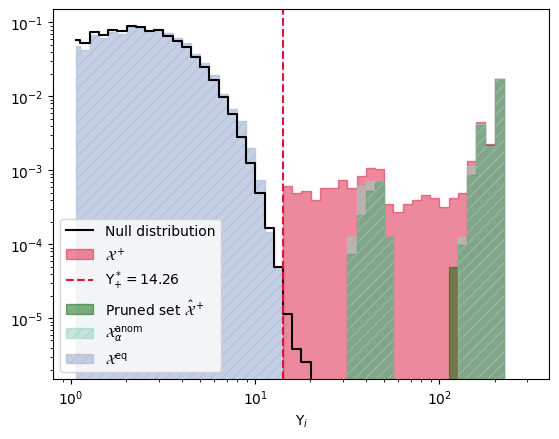

In [48]:
bins = np.logspace(0, 2.5, 51)
# bins = np.linspace(0, 120, 51)
cents = 0.5 * (bins[1:] + bins[:-1])
widths = np.diff(bins)
null_dist, _ = np.histogram(result_dict["stats_null"][p], bins=bins, density=False)
plt.step(cents, null_dist / np.sum(null_dist), where="mid", label="Null distribution", color='k', alpha=1, zorder=2)

# Upsilon_X, _ = np.histogram(result_dict["Upsilon_i_X"], bins=bins, density=False)
# plt.fill_between(cents, Upsilon_X / np.sum(Upsilon_X), step="mid", color=colours["red"], alpha=0.5, label=r"$\mathcal{X}$")

X_plus, _ = np.histogram(result_dict["Upsilon_i_X"][result_dict["X^+"]], bins=bins, density=False)
plt.fill_between(cents, X_plus / np.sum(Upsilon_X), step="mid", color=colours["red"], alpha=0.5, label=r"$\mathcal{X}^+$")

Upsilon_star_plus = result_dict["Upsilon_star_plus"][p_ext]
plt.axvline(Upsilon_star_plus, color=colours["red"], linestyle="--", label=r"$\Upsilon^*_{+}=$" + f"{Upsilon_star_plus:.2f}")

X_pruned, _ = np.histogram(result_dict["Upsilon_i_X"][result_dict["X_Pruned"][p_ext]], bins=bins, density=False)
plt.fill_between(cents, X_pruned / np.sum(Upsilon_X), step="mid", color="darkgreen", alpha=0.5, label=r"Pruned set $\hat\mathcal{X}^+$")

idx = [item for cluster in EE_book["X_OVER_clusters"].values() for item in cluster.get("Repechaged", [])]
X_repechage, _ = np.histogram(result_dict["Upsilon_i_X"][idx], bins=bins, density=False)
plt.fill_between(cents, X_repechage / np.sum(Upsilon_X), step="mid", color=colours["green"], hatch="///", alpha=0.5, label=r"$\mathcal{X}_\alpha^{\text{anom}}$")

X_eq, _ = np.histogram(Upsilon_i_equalized_X, bins=bins, density=False)
plt.fill_between(cents, X_eq / np.sum(Upsilon_X), step="mid", color=colours["lightblue"], hatch="///", alpha=0.7, label=r"$\mathcal{X}^{\mathrm{eq}}$", zorder=0)

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\Upsilon_i$")
plt.legend()

### Signal purity

In [51]:
S_SB_Y = EagleEye.S_SB_estimate_Y_overdensities(result_dict, EE_book)

In [52]:
S_SB_X = EagleEye.S_SB_estimate_X_overdensities(result_dict,EE_book)

In [56]:
S_SB_Y["Upsilon_alpha_plus"]

{0: 23.508901856862604,
 1: 37.493159452074714,
 2: 71.79971020609635,
 3: 69.12616806460561,
 4: 32.83137295703786}

In [62]:
S_SB_Y["Purity"]

{'Total': 0.860335258336572,
 0: 0.8866047730301772,
 1: 0.8624078240471067,
 2: 0.9280311376383655,
 3: 0.9097577640570266,
 4: 0.8095814209433579}

In [89]:
over_clusters = EE_book["Y_OVER_clusters"]
lenSo = len(np.concatenate([over_clusters[idx]["Repechaged"] for idx in list(over_clusters.keys())]))
lenBo = len(np.concatenate([over_clusters[idx]["Background"] for idx in list(over_clusters.keys())]))
lenWo = len(np.concatenate([over_clusters[idx]["Pruned"] for idx in list(over_clusters.keys())]))

In [101]:
n2 = len(result_dict["Upsilon_i_X"])
n1 = len(result_dict["Upsilon_i_Y"])
under_clusters = EE_book["X_OVER_clusters"]
lenWu = len(np.concatenate([under_clusters[idx]["Pruned"] for idx in list(under_clusters.keys())]))
denom = (lenBo * (n2 - lenWo) / (n1 - lenWu))
S_SB = lenSo - denom

In [ ]:
S_SB / np.sqrt(denom) # This value should be Normal distributed under the null, given the background count is sufficiently large

80.93447720437247